In [ ]:
!unzip /content/drive/MyDrive/ME781/checkpoints-20231114T172607Z-001.zip
!unzip /content/drive/MyDrive/ME781/datasets-20231114T172606Z-001.zip
!unzip /content/datasets/test.zip
!mv /content/test /content/datasets

Archive:  /content/drive/MyDrive/ME781/checkpoints-20231114T172607Z-001.zip
  inflating: checkpoints/gmm_final.pth  
  inflating: checkpoints/seg_final.pth  
  inflating: checkpoints/alias_final.pth  
Archive:  /content/drive/MyDrive/ME781/datasets-20231114T172606Z-001.zip
  inflating: datasets/test_pairs.txt  
  inflating: datasets/test.zip       
Archive:  /content/datasets/test.zip
   creating: test/
   creating: test/cloth/
  inflating: test/cloth/02783_00.jpg  
  inflating: test/cloth/07429_00.jpg  
  inflating: test/cloth/11028_00.jpg  
  inflating: test/cloth/11351_00.jpg  
  inflating: test/cloth/01430_00.jpg  
  inflating: test/cloth/03751_00.jpg  
  inflating: test/cloth/06802_00.jpg  
  inflating: test/cloth/08348_00.jpg  
  inflating: test/cloth/09933_00.jpg  
  inflating: test/cloth/06429_00.jpg  
  inflating: test/cloth/11791_00.jpg  
  inflating: test/cloth/01260_00.jpg  
   creating: test/cloth-mask/
  inflating: test/cloth-mask/02783_00.jpg  
  inflating: test/cloth-ma

In [ ]:
!cp /content/drive/MyDrive/ME781/* /content/

cp: -r not specified; omitting directory '/content/drive/MyDrive/ME781/assets'
cp: -r not specified; omitting directory '/content/drive/MyDrive/ME781/OpenPose'
cp: -r not specified; omitting directory '/content/drive/MyDrive/ME781/results'


In [ ]:
!pip install torchgeometry

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.7/42.7 kB 1.1 MB/s eta 0:00:00


In [ ]:
import os

import torch
from torch import nn
from torch.nn import functional as F
import torchgeometry as tgm

from datasets import VITONDataset, VITONDataLoader
from networks import SegGenerator, GMM, ALIASGenerator
from utils import gen_noise, load_checkpoint, save_images

In [ ]:
class Opts:
  def __init__(self):
    self.name='try'
    self.batch_size=1
    self.workers=1
    self.load_height=1024
    self.load_width=768
    self.dataset_dir='./datasets/'
    self.dataset_mode='test'
    self.dataset_list='test_pairs.txt'
    self.checkpoint_dir='./checkpoints/'
    self.save_dir='./results/'
    self.display_freq=1
    self.seg_checkpoint='seg_final.pth'
    self.gmm_checkpoint='gmm_final.pth'
    self.alias_checkpoint='alias_final.pth'
    self.semantic_nc=13
    self.init_type='xavier'
    self.init_variance=0.02
    self.grid_size=5
    self.norm_G='spectralaliasinstance'
    self.ngf=64
    self.num_upsampling_layers='most'
    self.shuffle=True


In [ ]:
def test(opt, seg, gmm, alias):
    up = nn.Upsample(size=(opt.load_height, opt.load_width), mode='bilinear')
    gauss = tgm.image.GaussianBlur((15, 15), (3, 3))
    gauss.cuda()

    test_dataset = VITONDataset(opt)
    test_loader = VITONDataLoader(opt, test_dataset)
    outputs=[]

    with torch.no_grad():
        for i, inputs in enumerate(test_loader.data_loader):
            img_names = inputs['img_name']
            c_names = inputs['c_name']['unpaired']

            img_agnostic = inputs['img_agnostic'].cuda()
            parse_agnostic = inputs['parse_agnostic'].cuda()
            pose = inputs['pose'].cuda()
            c = inputs['cloth']['unpaired'].cuda()
            cm = inputs['cloth_mask']['unpaired'].cuda()

            # Part 1. Segmentation generation
            parse_agnostic_down = F.interpolate(parse_agnostic, size=(256, 192), mode='bilinear')
            pose_down = F.interpolate(pose, size=(256, 192), mode='bilinear')
            c_masked_down = F.interpolate(c * cm, size=(256, 192), mode='bilinear')
            cm_down = F.interpolate(cm, size=(256, 192), mode='bilinear')
            seg_input = torch.cat((cm_down, c_masked_down, parse_agnostic_down, pose_down, gen_noise(cm_down.size()).cuda()), dim=1)

            parse_pred_down = seg(seg_input)
            parse_pred = gauss(up(parse_pred_down))
            parse_pred = parse_pred.argmax(dim=1)[:, None]

            parse_old = torch.zeros(parse_pred.size(0), 13, opt.load_height, opt.load_width, dtype=torch.float).cuda()
            parse_old.scatter_(1, parse_pred, 1.0)

            labels = {
                0:  ['background',  [0]],
                1:  ['paste',       [2, 4, 7, 8, 9, 10, 11]],
                2:  ['upper',       [3]],
                3:  ['hair',        [1]],
                4:  ['left_arm',    [5]],
                5:  ['right_arm',   [6]],
                6:  ['noise',       [12]]
            }
            parse = torch.zeros(parse_pred.size(0), 7, opt.load_height, opt.load_width, dtype=torch.float).cuda()
            for j in range(len(labels)):
                for label in labels[j][1]:
                    parse[:, j] += parse_old[:, label]

            # Part 2. Clothes Deformation
            agnostic_gmm = F.interpolate(img_agnostic, size=(256, 192), mode='nearest')
            parse_cloth_gmm = F.interpolate(parse[:, 2:3], size=(256, 192), mode='nearest')
            pose_gmm = F.interpolate(pose, size=(256, 192), mode='nearest')
            c_gmm = F.interpolate(c, size=(256, 192), mode='nearest')
            gmm_input = torch.cat((parse_cloth_gmm, pose_gmm, agnostic_gmm), dim=1)

            _, warped_grid = gmm(gmm_input, c_gmm)
            warped_c = F.grid_sample(c, warped_grid, padding_mode='border')
            warped_cm = F.grid_sample(cm, warped_grid, padding_mode='border')

            # Part 3. Try-on synthesis
            misalign_mask = parse[:, 2:3] - warped_cm
            misalign_mask[misalign_mask < 0.0] = 0.0
            parse_div = torch.cat((parse, misalign_mask), dim=1)
            parse_div[:, 2:3] -= misalign_mask

            output = alias(torch.cat((img_agnostic, pose, warped_c), dim=1), parse, parse_div, misalign_mask)

            unpaired_names = []
            for img_name, c_name in zip(img_names, c_names):
                unpaired_names.append('{}_{}'.format(img_name.split('_')[0], c_name))

            # save_images(output, unpaired_names, os.path.join(opt.save_dir, opt.name))

            if (i + 1) % opt.display_freq == 0:
                print("step: {}".format(i + 1))
            outputs.append(output)
    return outputs

In [ ]:
from IPython.display import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2

%matplotlib inline

In [ ]:
def main():
    opt=Opts()
    if not os.path.exists(os.path.join(opt.save_dir, opt.name)):
        os.makedirs(os.path.join(opt.save_dir, opt.name))

    seg = SegGenerator(opt, input_nc=opt.semantic_nc + 8, output_nc=opt.semantic_nc)
    gmm = GMM(opt, inputA_nc=7, inputB_nc=3)
    opt.semantic_nc = 7
    alias = ALIASGenerator(opt, input_nc=9)
    opt.semantic_nc = 13

    load_checkpoint(seg, os.path.join(opt.checkpoint_dir, opt.seg_checkpoint))
    load_checkpoint(gmm, os.path.join(opt.checkpoint_dir, opt.gmm_checkpoint))
    load_checkpoint(alias, os.path.join(opt.checkpoint_dir, opt.alias_checkpoint))

    seg.cuda().eval()
    gmm.cuda().eval()
    alias.cuda().eval()
    outputs=test(opt, seg, gmm, alias)
    return outputs

In [ ]:
test_cloth='/content/datasets/test/cloth/test.jpg'
test_cloth_mask='/content/datasets/test/cloth-mask/test.jpg'
def prepClothImg(imgPath):
  img=cv2.imread(imgPath)
  img_gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
  img_mask = 255*(img_gray<230).astype('uint8')
  cv2.imwrite(test_cloth,img)
  cv2.imwrite(test_cloth_mask,img_mask)

def tryCloth(imgPath):
  prepClothImg(imgPath)
  outputs=main()
  fig,axs=plt.subplots(1,2)
  axs[0].imshow(np.transpose(outputs[0].cpu().numpy()[0],(1,2,0)))
  axs[1].imshow(cv2.cvtColor(cv2.imread(test_cloth),cv2.COLOR_BGR2RGB))
  plt.show()


Network [SegGenerator] was created. Total number of parameters: 34.5 million. To see the architecture, do print(network).
Network [ALIASGenerator] was created. Total number of parameters: 100.5 million. To see the architecture, do print(network).


step: 1


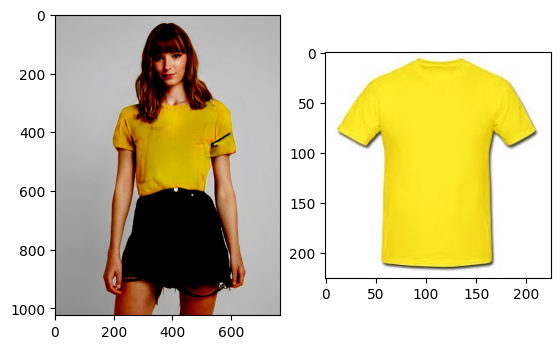

In [ ]:
path='/content/cloth.jpg'

tryCloth(path)

Network [SegGenerator] was created. Total number of parameters: 34.5 million. To see the architecture, do print(network).
Network [ALIASGenerator] was created. Total number of parameters: 100.5 million. To see the architecture, do print(network).


step: 1


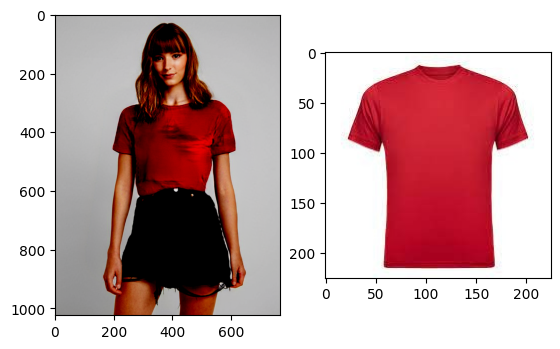

In [ ]:
path='/content/cloth2.jpg'

tryCloth(path)

Network [SegGenerator] was created. Total number of parameters: 34.5 million. To see the architecture, do print(network).
Network [ALIASGenerator] was created. Total number of parameters: 100.5 million. To see the architecture, do print(network).


step: 1


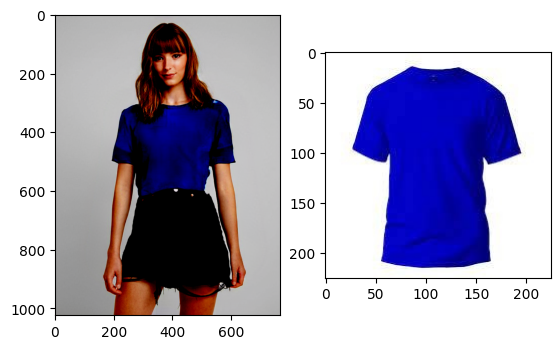

In [ ]:
path='/content/cloth3.jpg'

tryCloth(path)

Network [SegGenerator] was created. Total number of parameters: 34.5 million. To see the architecture, do print(network).
Network [ALIASGenerator] was created. Total number of parameters: 100.5 million. To see the architecture, do print(network).


step: 1


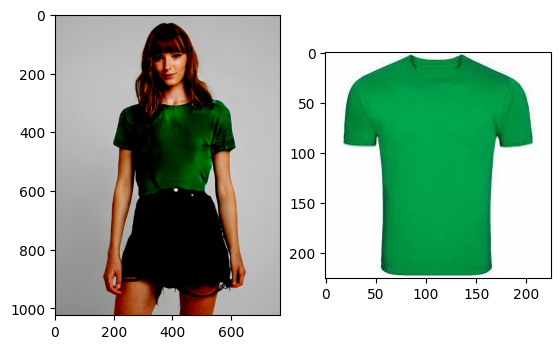

In [ ]:
path='/content/cloth4.jpg'

tryCloth(path)